In [1]:
import numpy as np
import pandas as pd
import numpy as np
import glob
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Fuel Consumption Data

This step imports the two raw fuel consumption rating datasets and loads them into pandas DataFrames for subsequent processing.

- `fc_df_95_14` contains fuel consumption records for model years **1995–2014**
- `fc_df_15_24` contains fuel consumption records for model years **2015–2024**


In [2]:
# Initial Loading of Fuel Consumption Datasets

url_95_14=r"C:\Users\agno3\OneDrive\Desktop\Coventry_Universty\7150CEM - Data Science Project - 2526JANMAY\CourseWorkAssessment\Drafts\Canada_Data_PINN_FuelConsumption\fuel_consumption_ratings\my1995-2014-fuel-consumption-ratings-5-cycle.csv"
url_15_24 =r"C:\Users\agno3\OneDrive\Desktop\Coventry_Universty\7150CEM - Data Science Project - 2526JANMAY\CourseWorkAssessment\Drafts\Canada_Data_PINN_FuelConsumption\fuel_consumption_ratings\my2015-2024-fuel-consumption-ratings.csv"
fc_df_95_14 = pd.read_csv(url_95_14)
fc_df_15_24 = pd.read_csv(url_15_24)

# Filtering Fuel Consumption Data for the Study Period (2011–2023)
fc_df_11_14 = fc_df_95_14[fc_df_95_14["Model year"]>=2011]
fc_df_15_23 = fc_df_15_24[fc_df_15_24["Model year"]<=2023]

# building unified fuel consumption dataset

fc_df_11_23 = pd.concat((fc_df_11_14,fc_df_15_23), axis = 0)
print(fc_df_11_23.shape)

(13595, 15)


In [3]:
fc_df_11_23

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
13527,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,9.5,30,219,NaN,NaN
13528,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,8.9,32,205,NaN,NaN
13529,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,10.0,28,230,NaN,NaN
13530,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,13.2,21,304,NaN,NaN
13531,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,11.9,24,274,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9264,2023,Volvo,XC40 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.2,7.9,9.2,31,215,5.0,5.0
9265,2023,Volvo,XC60 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.3,8.2,9.4,30,218,5.0,5.0
9266,2023,Volvo,XC60 B6 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,11.1,8.7,10.0,28,233,5.0,7.0
9267,2023,Volvo,XC90 B5 AWD,Sport utility vehicle: Standard,2.0,4,AS8,Z,10.5,8.4,9.6,29,223,5.0,5.0


## Loading Vehicle Specification Datasets (2011–2023)

Vehicle design specification data were provided as **separate CSV files for each model year**.  
To efficiently load and organise these files, a dynamic loading approach was implemented.

The workflow performs the following steps:

1. **Identify all specification files** in the vehicle specifications directory using `glob`.
2. **Iterate through each CSV file** detected in the folder.
3. **Extract the model year from the file name**.
4. **Load the dataset into a pandas DataFrame** using the `cp1252` encoding (required due to special characters in the original files).
5. **Store each DataFrame in a dictionary (`veh_spec_dfs`)**, where:
   - **Key** ==> model year (e.g., `2011`, `2012`, …)
   - **Value** ==> corresponding vehicle specification DataFrame.

This structure enables easy access to the vehicle specification dataset for a given year during the **fuel consumption - vehicle specification matching stage**.

In [4]:
# reading all vehicle specifications csv files
path = r"C:\Users\agno3\OneDrive\Desktop\Coventry_Universty\7150CEM - Data Science Project - 2526JANMAY\CourseWorkAssessment\Drafts\Canada_Data_PINN_FuelConsumption\vehicle_specifications"
files = glob.glob(path + r"\*.csv")

veh_spec_dfs = {}

for file in files:
    year = file[-11:-7]
    veh_spec_dfs[int(year)] = pd.read_csv(file, encoding="cp1252")

veh_spec_dfs

{2011:       MAKE                            MODEL  MYR   OL     OW    OH    WB  \
 0    ACURA  CSX 4DR SEDAN FWD /TECH PACKAGE    6  454  175.0  144.0  270   
 1    ACURA      MDX 4DR SUV AWD /TECH/ELITE   10  485  199.0  173.0  275   
 2    ACURA    RDX 4DR SUV AWD /TECH PACKAGE   10  462  187.0  166.0  265   
 3    ACURA          RL 4DR SEDAN AWD /ELITE    9  497  185.0  146.0  280   
 4    ACURA     TL 4 DR SEDAN FWD/TECHNOLOGY    9  497  188.0  145.0  278   
 ..     ...                              ...  ...  ...    ...    ...  ...   
 849  VOLVO        V50 4DR WAGON FWD 2.4i/T5    5  451  177.0  143.0  265   
 850  VOLVO         XC60 4DR 3.2 FWD/AWD SUV    9  463  189.0  171.0  277   
 851  VOLVO              XC60 4DR T6 AWD SUV    9  463  189.0  171.0  277   
 852  VOLVO        XC70 4DR WAGON AWD 3.2/T6    8  484  187.0  160.0  282   
 853  VOLVO             XC90 4DR SUV AWD 3.2    2  480  190.0  178.0  286   
 
         CW       A      B     C     D      E      F      G    TWF  

## Consolidating Datasets for Quality Control (QC)

To streamline the application of quality control and preprocessing functions, all datasets were consolidated into a single dictionary (`all_dfs`).

This dictionary contains:

- **Vehicle specification datasets** for each model year (2011–2023), stored with the model year as the key.
- **Fuel consumption dataset (`fc_df_11_23`)**, which contains the filtered fuel consumption records for the same period.

The vehicle specification dictionary (`veh_spec_dfs`) is first copied to preserve the original structure.  
The fuel consumption DataFrame is then added to the dictionary under the key `"fc_df_11_23"`.

This unified structure allows QC, profiling, and preprocessing functions to be **applied consistently across all datasets through iteration**, improving the reproducibility and clarity of the data construction pipeline.

In [5]:
# combining all dataframes in one dictionary to iterate in QCs functions
all_dfs = veh_spec_dfs.copy()
all_dfs["fc_df_11_23"] = fc_df_11_23
all_dfs

{2011:       MAKE                            MODEL  MYR   OL     OW    OH    WB  \
 0    ACURA  CSX 4DR SEDAN FWD /TECH PACKAGE    6  454  175.0  144.0  270   
 1    ACURA      MDX 4DR SUV AWD /TECH/ELITE   10  485  199.0  173.0  275   
 2    ACURA    RDX 4DR SUV AWD /TECH PACKAGE   10  462  187.0  166.0  265   
 3    ACURA          RL 4DR SEDAN AWD /ELITE    9  497  185.0  146.0  280   
 4    ACURA     TL 4 DR SEDAN FWD/TECHNOLOGY    9  497  188.0  145.0  278   
 ..     ...                              ...  ...  ...    ...    ...  ...   
 849  VOLVO        V50 4DR WAGON FWD 2.4i/T5    5  451  177.0  143.0  265   
 850  VOLVO         XC60 4DR 3.2 FWD/AWD SUV    9  463  189.0  171.0  277   
 851  VOLVO              XC60 4DR T6 AWD SUV    9  463  189.0  171.0  277   
 852  VOLVO        XC70 4DR WAGON AWD 3.2/T6    8  484  187.0  160.0  282   
 853  VOLVO             XC90 4DR SUV AWD 3.2    2  480  190.0  178.0  286   
 
         CW       A      B     C     D      E      F      G    TWF  

# Data Construction
The dataset construction stage relies on matching **fuel consumption vehicle characteristics** `Model year`, `Make`, `Model`, `Vehicle class`, `Engine size`, `Cylinders` with `MAKE`, `MODEL` in **vehicle specification**

Vehicle model names and related textual fields in both files often contain **formatting inconsistencies, marketing terms, and special characters** that may hinder reliable matching between datasets.  **`Example 1`**, **`Example 2`**, **`Example 3`**

## Examples
### Example 1
**Fuel Dataset**

|   Model year  |      Make      |   Model       | Vehicle class  | Engine size   | Cylinders      |fuel_consumption_tokens| 
| ------------- | -------------- | ------------- | -------------- | ------------- | -------------- |---- |
|     2011       |   Acura  |     CSX       |   Compact   |      2.0      |      4         |{2.0, csx, v4}|

**`2011` Vehicle Specification Dataset**

|   MAKE       | MODEL  |vehicle_specification_token|
| ------------- | -------------- |----|
|     ACURA       |   CSX 4DR SEDAN FWD /TECH PACKAGE   | {sedan, csx, 4dr, fwd}|


### Example 2
**Fuel Dataset**

| Model year | Make | Model | Vehicle class | Engine size | Cylinders | fuel_consumption_tokens |
|-------------|------|------|--------------|-------------|-----------|--------------------------|
| 2016 | Toyota | 4Runner 4WD | Sport utility vehicle: Standard | 4.0 | 6 | {suv, 4runner, 4.0, 4wd, v6} |

**`2016` Vehicle Specification Dataset**

| MAKE | MODEL | vehicle_specification_token |
|------|------|------------------------------|
| TOYOTA | 4RUNNER 4DR SUV 4WD LIMITED V6 | {4runner, 4wd, v6, suv, 4dr, limited} |


### Example 3
**Fuel Dataset**

| Model year | Make | Model | Vehicle class | Engine size | Cylinders | fuel_consumption_tokens |
|-------------|------|------|--------------|-------------|-----------|--------------------------|
| 2014 | Acura | TL AWD | Mid-size | 3.7 | 6 | {tl, awd, 3.7, v6} |

**`2014` Vehicle Specification Dataset**

| MAKE | MODEL | vehicle_specification_token |
|------|------|------------------------------|
| ACURA | TL 4 DR SEDAN SH-AWD/SH-AWD TECHNOLOGY | {tl, awd, sedan, 4dr} |



These inconsistencies must first be identified and standardised.


## A. Text Normalisation

Text normalisation is therefore applied to reduce formatting variation and improve the robustness of the matching process.

The normalisation strategy includes:

1. **Special character handling**  & **Case standardisation**  
  Identifying punctuation or formatting artefacts that may appear in model names. Then, convert all textual fields to a consistent lowercase format.

2. **Fuel Consumption Token Standardisation**  
  Harmonising equivalent expressions into a unified representation  
  *(e.g., “4 door” → “4dr”, “sport utility vehicle” → “suv”)*.

3. **Vehicle Specifications Noise Removal**  
  Removing non-informative marketing or trim descriptors that do not affect the physical vehicle configuration  
  *(e.g., “technology”, “package”, or similar promotional terms)*.


### 1. Special character handling & Case standardisation

The function `special_char_profiler()` scans all **string columns** in a dataframe and identifies:

- The **frequency of special characters** that fall outside alphanumeric characters, commas, and spaces.
- The presence of **multiple or double spaces**, which often appear after text concatenation or manual formatting.

The output is a dictionary structured as:

- **Key** → column name  
- **Value** → dictionary of detected special characters and their counts

This diagnostic step supports the design of **targeted normalisation rules**, ensuring that cleaning operations are **data-driven rather than arbitrary**.

In [6]:
def special_char_profiler(df):
    """
    Count special characters in all string columns.

    Parameters
    ----------
        df : pandas.DataFrame

    Returns
    -------
        dictionary where key ==> column name & value ==> special character counts
    """

    pattern = r"[^A-Za-z0-9,\s]"
    result = {}

    string_cols = df.select_dtypes(include=["object", "string"]).columns

    for col in string_cols:
        counter = Counter()
        #print(counter)

        for val in df[col].dropna().astype(str):
            # count special characters
            chars = re.findall(pattern, val)
            counter.update(chars)
            # count double or multiple spaces
            double_spaces = re.findall(r" {2,}", val)
            if double_spaces:
                counter["  "] += len(double_spaces)
        if counter:
            #print(counter)
            #print(dict(counter))
            result[col] = dict(counter)
        else:
            result[col] = {"special charachters":0}
    return result


To ensure consistency across the entire data construction pipeline, this profiling procedure is implemented through a loop that iterates over the dictionary `all_dfs`, which contains all datasets **`fuel consumption dataset`** & **`vehicle specification datasets for each model year`** used in the join process.

For each dataframe:

1. The `special_char_profiler()` function is executed.
2. The detected special characters from each column are extracted.
3. All identified characters are aggregated into a **master set of unique special characters** (`all_special_chars`).

This consolidated list provides a **global view of formatting anomalies across the full dataset collection** and is subsequently used to define a **standardised character cleaning strategy** during the text normalisation stage.

To ensure consistency across the entire data construction pipeline, this procedure is implemented through a loop that iterates over the dictionary `all_dfs`, which contains all datasets used in the join process, including the **`fuel consumption dataset`** and the **`vehicle specification datasets for each model year`**.

For each dataframe:

1. The `special_char_profiler()` function is executed to identify special characters present in each string column.
2. The detected special characters from each column are extracted.
3. All identified characters are aggregated into a **master set of unique special characters** (`all_special_chars`).

This consolidated list provides a **global view of formatting anomalies across the full dataset collection** and is subsequently used to define a **standardised character cleaning strategy** during the text normalisation stage.


In [7]:
# Inspect special characters across all input datasets (yearly vehicle specification DataFrames and the fuel consumption DataFrame)
# to compile a master list of formatting artefacts to be removed during the text normalisation stage
all_special_chars = set()
for k, v in all_dfs.items():
    #print(k)
    df_special_charc_dict = special_char_profiler(v)
    #print(k, "\n", df_special_charc_dict)
    # compiling all special characters 
    for col_dict in df_special_charc_dict.values():
        #print(col_dict)
        all_special_chars.update(col_dict.keys())
        #print(all_special_chars)
print("\nunique set of special characters ==> ", all_special_chars)


unique set of special characters ==>  {'_', 'á', '&', ')', '.', '/', 'special charachters', ':', '-', 'é', '  ', "'", '+', '('}



The standardisation process includes:

- Converting all text to **lowercase** to enforce case consistency.
- **Removing special characters** by replacing them with spaces.
- **Collapsing multiple spaces** into a single space using regex.
- **Trimming leading and trailing spaces**.

Double or repeated spaces are handled separately to ensure proper token separation.

The resulting `_std` columns provide **clean, normalised textual representations of the original fields**, which are subsequently used in downstream steps such as **token generation and fuzzy matching between fuel consumption and vehicle specification datasets**.

In [8]:
# standardising vehicle model to match transport CSV acronyms in model fields
for k, v in all_dfs.items():
    df_special_charc_dict = special_char_profiler(v)
    #print("\n", k)
    #print(df_special_charc_dict)

    for col, special_charc_dic in df_special_charc_dict.items():
        #print(col, "==>", special_charc_dic, "==>", len(special_charc_dic))

        if len(special_charc_dic) > 1:
            #print(col)

            v[col + "_std"] = v.loc[:, col].astype("string").str.lower()

            for charc in special_charc_dic.keys():
                #print(charc)

                if charc == "  ":
                    v[col + "_std"] = (
                        v[col + "_std"]
                        .str.replace(r"\s{2,}", " ", regex=True)
                        .str.strip()
                        .str.lower())
                else:
                    v[col + "_std"] = (
                        v[col + "_std"]
                        .str.replace(charc, " ", regex=False)
                        .str.replace(r"\s{2,}", " ", regex=True)
                        .str.strip()
                        .str.lower())

#### Inspect the 2011 Vehicle Specification DataFrame to Validate the Standardised Model Field (`MODEL_std`)

In [9]:
all_dfs[2011].head()

,MAKE,MODEL,MYR,OL,OW,OH,WB,CW,A,B,C,D,E,F,G,TWF,TWR,WDIST,MODEL_std
0,ACURA,CSX 4DR SEDAN FWD /TECH PACKAGE,6,454,175.0,144.0,270,1300.0,94.0,45.0,36.0,76.0,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package
1,ACURA,MDX 4DR SUV AWD /TECH/ELITE,10,485,199.0,173.0,275,2064.0,117.0,183.0,42.0,85.0,126.0,100.0,110.0,172.0,172.0,56/44,mdx 4dr suv awd tech elite
2,ACURA,RDX 4DR SUV AWD /TECH PACKAGE,10,462,187.0,166.0,265,1790.0,125.0,152.0,38.0,84.0,124.0,98.0,99.0,158.0,159.0,57/43,rdx 4dr suv awd tech package
3,ACURA,RL 4DR SEDAN AWD /ELITE,9,497,185.0,146.0,280,1864.0,125.0,73.0,37.0,80.0,116.0,104.0,111.0,157.0,157.0,58/42,rl 4dr sedan awd elite
4,ACURA,TL 4 DR SEDAN FWD/TECHNOLOGY,9,497,188.0,145.0,278,1682.0,134.0,62.0,34.0,81.0,117.0,105.0,115.0,160.0,161.0,61/39,tl 4 dr sedan fwd technology


#### Inspect the Fuel Consumption DataFrame to Validate the Standardised Model Field (`Model_std`, `Vehicle class_std`)

In [10]:
all_dfs["fc_df_11_23"].head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating,Model_std,Vehicle class_std
13527,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,9.5,30,219,NaN,NaN,csx,compact
13528,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,8.9,32,205,NaN,NaN,csx,compact
13529,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,10.0,28,230,NaN,NaN,csx,compact
13530,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,13.2,21,304,NaN,NaN,mdx awd,sport utility vehicle
13531,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,11.9,24,274,NaN,NaN,rdx awd turbo,sport utility vehicle


### 2. **Fuel Consumption Token Standardisation**

To ensure compatibility between the **fuel consumption dataset** and the **vehicle specification catalogue**, selected fields in the fuel dataset were standardised to match the token formats used in the vehicle specification records.

This step focuses on harmonising textual tokens that describe vehicle characteristics so that equivalent concepts share a consistent representation across both datasets.

The standardisation was applied to the following fields:

- **`Vehicle class_std`**  
  Vehicle class descriptions were simplified to match the terminology used in the vehicle specification catalogue.  
  Size descriptors such as *subcompact*, *compact*, *mid-size*, *full-size*, *small*, and *standard* were removed because they are not present in the specification datasets. In addition, the phrase **“sport utility vehicle”** was standardised to **“suv”**, and **“pickup”** was converted to **“p/u”** to align with the catalogue notation.

- **`cylinders_std`**  
  Cylinder information was converted into the format used in the specification data by prefixing the cylinder count with **“V”** (e.g., `6 → V6`, `4 → V4`).

- **`Model_std`**  
  Door number formatting was standardised to match the vehicle specification records by converting expressions such as **“4 door” → “4dr”**.

These transformations ensure that semantically equivalent attributes are represented using **consistent tokens**, improving the reliability of the subsequent **token-based fuzzy matching process used to join fuel consumption records with vehicle specification datasets**.

In [11]:
# Implement token standardisation in `Vehicle class_std`, `cylinders_std`, `Model_std` to match the format specified in the vehicle specification data catalogue
# remove subcompact,..etc because it doesn't exist in vehicle specification hseets
all_dfs["fc_df_11_23"]["Vehicle class_std"] =(fc_df_11_23.loc[:,"Vehicle class"].str.lower()
                                              .str.replace("pickup","p/u")
                                              .str.replace("subcompact","")
                                              .str.replace("minicompact","")
                                              .str.replace("compact","")
                                              .str.replace("mid-size","")
                                              .str.replace("full-size","")
                                              .str.replace("small","")
                                              .str.replace("standard","")
                                              .str.replace("sport utility vehicle","suv")
                                              .str.replace(":","")
                                              .str.strip())

all_dfs["fc_df_11_23"]["cylinders_std"] = "V" + all_dfs["fc_df_11_23"]["Cylinders"].astype(str)

# standadise door numbers format to match the vehicle specification data catalogue
all_dfs["fc_df_11_23"]["Model_std"] = all_dfs["fc_df_11_23"].loc[:,"Model_std"].str.replace(" door","dr")

#print(all_dfs["fc_df_11_23"]["Model_std"].value_counts())
print(all_dfs["fc_df_11_23"]["Vehicle class_std"].value_counts(),"\n")
print(all_dfs["fc_df_11_23"]["cylinders_std"].value_counts())


Vehicle class_std
                           6452
suv                        3795
p/u truck                  1422
two-seater                  858
station wagon               557
van passenger               158
minivan                     147
special purpose vehicle     118
van cargo                    88
Name: count, dtype: int64 

cylinders_std
V4     5590
V6     4468
V8     2879
V12     288
V3      165
V5       95
V10      94
V16      14
V2        2
Name: count, dtype: int64


In [12]:
all_dfs["fc_df_11_23"]

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating,Model_std,Vehicle class_std,cylinders_std
13527,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,9.5,30,219,NaN,NaN,csx,,V4
13528,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,8.9,32,205,NaN,NaN,csx,,V4
13529,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,10.0,28,230,NaN,NaN,csx,,V4
13530,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,13.2,21,304,NaN,NaN,mdx awd,suv,V6
13531,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,11.9,24,274,NaN,NaN,rdx awd turbo,suv,V4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9264,2023,Volvo,XC40 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.2,7.9,9.2,31,215,5.0,5.0,xc40 b5 awd,suv,V4
9265,2023,Volvo,XC60 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.3,8.2,9.4,30,218,5.0,5.0,xc60 b5 awd,suv,V4
9266,2023,Volvo,XC60 B6 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,11.1,8.7,10.0,28,233,5.0,7.0,xc60 b6 awd,suv,V4
9267,2023,Volvo,XC90 B5 AWD,Sport utility vehicle: Standard,2.0,4,AS8,Z,10.5,8.4,9.6,29,223,5.0,5.0,xc90 b5 awd,suv,V4


### 3. **Vehicle Specification Token Cleaning, Normalisation, and Creation of `model_fuzzy_key`**

Vehicle specification model descriptions often include **trim-level identifiers, marketing labels, and formatting variations** that do not influence the underlying vehicle configuration. These elements can introduce noise during the token-based matching process.

To improve matching reliability, the `MODEL_std` field in each yearly vehicle specification dataset is cleaned and normalised before generating the token key.

The following transformations are applied:

- **Trim and marketing noise removal**  
  Non-informative descriptors such as *“tech”*, *“technology”*, and *“package”* are removed because they represent optional equipment rather than core vehicle characteristics.

- **Drivetrain standardisation**  
  Variants such as **“sh awd”** are normalised to **“awd”** to ensure consistent drivetrain representation.

- **Door format standardisation**  
  Door descriptors are harmonised to match the token format used during fuzzy matching  
  *(e.g., “4 dr” → “4dr”, “2 dr” → “2dr”, “door” → “dr”)*.

- **Whitespace normalisation**  
  Multiple spaces are collapsed into a single space, and leading or trailing spaces are removed.

After cleaning, the resulting model description is:

1. Converted to lowercase  
2. Split into tokens  
3. Converted into a **set representation (`model_fuzzy_key`)**

This token set provides a **standardised representation of the vehicle model configuration**, enabling consistent comparison with the token keys generated from the fuel consumption dataset during the fuzzy matching stage.

In addition, the manufacturer name is standardised by converting the `MAKE` field to lowercase (`make_std`) to support case-insensitive matching.

The cleaned datasets are then exported for inspection and traceability during the dataset construction process.

In [13]:
for year in range(2011, 2024):

    year_df = all_dfs[year]

    year_df["model_fuzzy_key"] = (year_df["MODEL_std"]
                                     .str.replace("sh awd", "awd", regex=False)
                                     .str.replace("tech", "", regex=False)
                                     .str.replace("package", "", regex=False)
                                     .str.replace("technology", "", regex=False)
                                     .str.replace(" door", "dr", regex=False)
                                     .str.replace("4 dr", "4dr", regex=False)
                                     .str.replace("2 dr", "2dr", regex=False)
                                     .str.replace(r"\s+", " ", regex=True)
                                     .str.strip()
                                     .str.lower()
                                     .str.split()
                                     .apply(set))
    year_df["make_std"] = year_df.loc[:,"MAKE"].str.lower()
    # backup step
    #year_df.to_csv(f"year_df_{year}.csv", index=False)

In [14]:
all_dfs[2011].head()

,MAKE,MODEL,MYR,OL,OW,OH,WB,CW,A,B,...,D,E,F,G,TWF,TWR,WDIST,MODEL_std,model_fuzzy_key,make_std
0,ACURA,CSX 4DR SEDAN FWD /TECH PACKAGE,6,454,175.0,144.0,270,1300.0,94.0,45.0,...,76.0,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura
1,ACURA,MDX 4DR SUV AWD /TECH/ELITE,10,485,199.0,173.0,275,2064.0,117.0,183.0,...,85.0,126.0,100.0,110.0,172.0,172.0,56/44,mdx 4dr suv awd tech elite,"{awd, 4dr, elite, mdx, suv}",acura
2,ACURA,RDX 4DR SUV AWD /TECH PACKAGE,10,462,187.0,166.0,265,1790.0,125.0,152.0,...,84.0,124.0,98.0,99.0,158.0,159.0,57/43,rdx 4dr suv awd tech package,"{awd, 4dr, rdx, suv}",acura
3,ACURA,RL 4DR SEDAN AWD /ELITE,9,497,185.0,146.0,280,1864.0,125.0,73.0,...,80.0,116.0,104.0,111.0,157.0,157.0,58/42,rl 4dr sedan awd elite,"{awd, 4dr, rl, elite, sedan}",acura
4,ACURA,TL 4 DR SEDAN FWD/TECHNOLOGY,9,497,188.0,145.0,278,1682.0,134.0,62.0,...,81.0,117.0,105.0,115.0,160.0,161.0,61/39,tl 4 dr sedan fwd technology,"{4dr, tl, fwd, sedan, nology}",acura


## B. Tokenisation
### Construction of the Fuel Consumption Token Key (`model_fuzzy_key`)

To support the fuzzy matching process between the **fuel consumption dataset** and the **vehicle specification datasets**, a token-based key was constructed for each fuel consumption record.

The objective of this key is to represent the **core physical and configuration attributes of a vehicle**, while excluding identifiers such as **Make** and **Model year**, which are handled separately during the matching process.

The token key (`model_fuzzy_key`) is created by combining multiple standardised attributes into a **set of tokens**, including:

- **`Model_std`** → tokenised model description  
- **`Engine size (L)`** → engine displacement  
- **`Vehicle class_std`** → standardised vehicle class tokens  
- **`cylinders_std`** → cylinder configuration (e.g., `v4`, `v6`)

For each record, these elements are converted into tokens and merged into a **single set representation**. Using a set ensures that:

- duplicate tokens are automatically removed  
- the token collection can be directly used in **set-based similarity measures** such as **Jaccard similarity**

The resulting `model_fuzzy_key` therefore captures a **compact structural description of the vehicle**, which improves the robustness of the subsequent **token-based fuzzy matching strategy used to link fuel consumption records with the corresponding vehicle specification entries**.

In [15]:
# build tokens key set that include everthing about the vehicle except Make and model year

all_dfs["fc_df_11_23"]["model_fuzzy_key"] = all_dfs["fc_df_11_23"].apply(
    lambda row: (
        set(str(row["Model_std"]).lower().split())
        | {str(row["Engine size (L)"])}
        | set(str(row["Vehicle class_std"]).lower().split())
        | {str(row["cylinders_std"])
           .lower()}
    ), axis=1)

all_dfs["fc_df_11_23"]

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating,Model_std,Vehicle class_std,cylinders_std,model_fuzzy_key
13527,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,9.5,30,219,NaN,NaN,csx,,V4,"{2.0, v4, csx}"
13528,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,8.9,32,205,NaN,NaN,csx,,V4,"{2.0, v4, csx}"
13529,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,10.0,28,230,NaN,NaN,csx,,V4,"{2.0, v4, csx}"
13530,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,13.2,21,304,NaN,NaN,mdx awd,suv,V6,"{awd, mdx, 3.7, v6, suv}"
13531,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,11.9,24,274,NaN,NaN,rdx awd turbo,suv,V4,"{awd, rdx, v4, turbo, 2.3, suv}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9264,2023,Volvo,XC40 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.2,7.9,9.2,31,215,5.0,5.0,xc40 b5 awd,suv,V4,"{awd, suv, xc40, 2.0, v4, b5}"
9265,2023,Volvo,XC60 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.3,8.2,9.4,30,218,5.0,5.0,xc60 b5 awd,suv,V4,"{awd, suv, 2.0, v4, xc60, b5}"
9266,2023,Volvo,XC60 B6 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,11.1,8.7,10.0,28,233,5.0,7.0,xc60 b6 awd,suv,V4,"{awd, suv, 2.0, v4, xc60, b6}"
9267,2023,Volvo,XC90 B5 AWD,Sport utility vehicle: Standard,2.0,4,AS8,Z,10.5,8.4,9.6,29,223,5.0,5.0,xc90 b5 awd,suv,V4,"{awd, suv, 2.0, xc90, v4, b5}"


## C. Token-Based Similarity (Jaccard Similarity)

The similarity between two token sets is computed using **Jaccard similarity**:

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$

**Where:**

- **A** = token set from the **fuel consumption dataset**
- **B** = token set from the **vehicle specification dataset**
- **$(A \cap B)$** = number of tokens in the **intersection** between the two sets
- **$(A \cup B)$** = number of tokens in the **union** of both sets

## D. Best-Match Selection

To integrate the fuel consumption dataset with the yearly vehicle specification catalogues, a token-based fuzzy matching procedure was implemented using the **`veh_fc_specs_joiner()`** function. The function identifies the most suitable vehicle specification record for each fuel consumption record based on model-related token similarity.

The **`veh_fc_specs_joiner()`** workflow is as follows:

1. Filter the fuel consumption dataset to retain only records for the selected model year.
2. Group vehicle specification model token keys by manufacturer (`make_std`) to restrict candidate matching to vehicles of the same make.
3. For each fuel consumption record, compare its token key against all candidate vehicle specification token keys within the same manufacturer group.
4. Compute model similarity using **Jaccard similarity**, based on the intersection and union of the previously constructed token sets.
5. Select the candidate vehicle specification record with the highest similarity score as the best match.
6. When multiple candidates achieve the same similarity score, tie-breaking rules are applied sequentially:
   - prefer the match with the larger number of **strong tokens** in the intersection, excluding weak (general) technical tokens such as `v6`, `awd`, `fwd`, `rwd`, and drivetrain patterns;
   - if still tied, prefer the match with the **larger intersection size**;
   - if still tied, prefer the match with the **smaller union size**.
7. Store the selected match and merge the matched vehicle specification record back with the yearly fuel consumption subset.

The function returns a final merged dataframe containing the yearly fuel consumption records together with their selected vehicle specification matches.

In [16]:
def veh_fc_specs_joiner(dfs_dict, input_year):
    """
    Fuzzy-match fuel consumption records with vehicle specification records for a given year using token-based Jaccard similarity staregy

    --------------------
    Parameters
    --------------------
    dfs_dict : Dictionary of DataFrames containing the vehicle specification & fuel consumption datasets.
    
    Must include:
        - "fc_df_11_23": fuel consumption data with tokenised `model_fuzzy_key`
        - yearly vehicle specification DataFrames keyed by year.

    input_year : int
        Model year used to filter fuel consumption records and select the corresponding
        vehicle specification dataset.
    
    --------------------
    Outputs (returns)
    --------------------
    
    1. fc_df_year_veh_spec_all:
            Final merged dataframe linking fuel consumption records with matched vehicle
            specifications for the specified year using fuzzy keys.
    2. Other outputs:
            Additional dataframes containing intermediate matching diagnostics.
    """
    fuzzy_best_match = {}

    import re
    
    weak_tokens = [re.compile(r"^v\d+$"),
                   re.compile(r"^\d+wd$"),
                   re.compile(r"^4x4$"),
                   re.compile(r"^awd$"),
                   re.compile(r"^fwd$"),
                   re.compile(r"^rwd$")]
    
    def remove_weak_tokens(token_set):
        """Remove weak tokens from a token set using regex matching."""
        strong_tokens = set()
    
        for token in token_set:
            token = str(token).lower().strip()
    
            if not any(pattern.fullmatch(token) for pattern in weak_tokens):
                strong_tokens.add(token)
        return strong_tokens
        
    vehicle_make_models= dfs_dict[input_year][["make_std","model_fuzzy_key"]].groupby("make_std")["model_fuzzy_key"].apply(list).to_dict()
    fc_df_year = dfs_dict["fc_df_11_23"][dfs_dict["fc_df_11_23"]["Model year"] == input_year].reset_index(drop=True)
    for i in range(len(fc_df_year)):
    #for i in range(len(dfs_dict["fc_df_11_23"][dfs_dict["fc_df_11_23"]["Model year"] == input_year])):
    
        fc_veh_make = str(fc_df_year.iloc[i, 1]).lower().strip()
        fc_veh_key  = fc_df_year.iloc[i, -1]
    
        # ensure set
    #    if not isinstance(fc_veh_key, set):
    #        fc_veh_key = set(str(fc_veh_key).lower().split())
    #
        if fc_veh_make in vehicle_make_models:
            tr_veh_spec_models = vehicle_make_models[fc_veh_make]
        else:
            print(f"no specs found for {fc_veh_make} in {input_year} vehicles")
            tr_veh_spec_models = set()
    
        # list to temporarily store all possible match scores (your variables)
        best_similarity_score = 0
        best_intersection_len = 0
        best_union_len = 0
        best_intersection = set()
        tie_counts = 0
    
    #    best_model_key = None  # not changing your list; just to avoid NameError
        best_model_key = set()  # not changing your list; just to avoid NameError
    
        for possible_model in tr_veh_spec_models:
            #if not isinstance(possible_model, set):
             #   possible_model = set(str(possible_model).lower().split())
    
            models_union = possible_model | fc_veh_key
            union_len = len(models_union)
            #if union_len == 0:
             #   continue
    
            models_intersection = possible_model & fc_veh_key
            intersection_len = len(models_intersection)
            similarity_ratio = intersection_len / union_len
    
            # new best
            if similarity_ratio > best_similarity_score:
                best_similarity_score = similarity_ratio
                best_intersection_len = intersection_len
                best_union_len = union_len
                best_intersection = models_intersection
                best_model_key = possible_model
                tie_counts = 0

########################################
            # tie -> choose best using tie-break rules
            elif similarity_ratio == best_similarity_score and best_similarity_score != 0:
                tie_counts += 1
            
                # tie-break 0 (stronger overlap): more non-weak tokens in intersection
                best_strong_tokens = remove_weak_tokens(best_intersection)
                curr_strong_tokens = remove_weak_tokens(models_intersection)
            
                best_strong = len(best_strong_tokens)
                curr_strong = len(curr_strong_tokens)
            
                if curr_strong > best_strong and len(curr_strong_tokens) != 0:
                    best_intersection_len = intersection_len
                    best_union_len = union_len
                    best_intersection = models_intersection
                    best_model_key = possible_model
            
                elif curr_strong == best_strong:
                    # tie-break 1: larger intersection
                    if intersection_len > best_intersection_len:
                        best_intersection_len = intersection_len
                        best_union_len = union_len
                        best_intersection = models_intersection
                        best_model_key = possible_model
            
                    # tie-break 2: smaller union
                    elif intersection_len == best_intersection_len and union_len < best_union_len:
                        best_union_len = union_len
                        best_intersection = models_intersection
                        best_model_key = possible_model
    
        # store best for this i (after checking all candidates)
        fuzzy_best_match[i] = [tie_counts, best_similarity_score, best_intersection, fc_veh_key, best_model_key]
    model_matching_df = pd.DataFrame(fuzzy_best_match).transpose()
    header = ["ties", "similarity ratio", "join intersection", "fc_join_key", "veh_spec_join_key"]
    model_matching_df.columns = header
    fc_df_year = dfs_dict["fc_df_11_23"][dfs_dict["fc_df_11_23"]["Model year"] == input_year].reset_index(drop=True)
    veh_spec_year_df = dfs_dict[input_year].copy()
    fc_df_year_all_keys = pd.concat([fc_df_year, model_matching_df], axis=1)

    # make join keys hashable for merge & value counts
        # ifinstance in ==> lambda key: frozenset(key) if isinstance(key, set) else key) to handle none set keys if existed
    fc_df_year_all_keys["veh_spec_join_key_hash"] = fc_df_year_all_keys["veh_spec_join_key"].apply(
        lambda key: frozenset(key) if isinstance(key, set) else key)
    veh_spec_year_df["model_fuzzy_key_hash"] = veh_spec_year_df["model_fuzzy_key"].apply(
        lambda key: frozenset(key) if isinstance(key, set) else key)

    fc_df_year_veh_spec_all = pd.merge(
        fc_df_year_all_keys,
        veh_spec_year_df,
        how="left",
        left_on="veh_spec_join_key_hash",
        right_on="model_fuzzy_key_hash"
    )

    #fc_df_year_veh_spec_all = pd.merge(fc_df_year, veh_spec_year_df, how='left', on='model_fuzzy_key')
    return(fc_df_year_veh_spec_all)
    #return(model_matching_df, fc_df_year, veh_spec_year_df, fc_df_year_all_keys, fc_df_year_veh_spec_all)
    #print(fc_veh_make)
    #print(fc_veh_key)
    #print("\n", tr_veh_spec_models, "\n")
    #print(vehicle_make_models["jeep"])
    #print(best_similarity_score)
    #print(best_intersection_len)
    #print(best_union_len)
    #print(best_intersection)
    #print(best_model_key)
    #print(tie_counts)

### E. Final Dataset Construction

After defining the fuzzy matching procedure, the **`veh_fc_specs_joiner()`** function is applied sequentially to each model year between **2011 and 2023**.

For each year:

1. The corresponding subset of the **fuel consumption dataset** is selected.
2. The fuzzy matching procedure is executed against the **vehicle specification dataset for that year**.
3. The resulting merged dataframe containing matched vehicle specifications is stored in a dictionary (`fc_veh_spec_all_dfs`), where the **key represents the model year** and the **value contains the merged dataset for that year**.

Once the yearly matching process is completed, the resulting datasets are consolidated into a single analysis-ready dataframe through the following steps:

- Each yearly merged dataframe is appended to a list (`all_years_dfs`).
- The list of yearly datasets is concatenated using `pd.concat()` to produce a unified dataset (`fc_veh_spec_all`).

The resulting dataframe **`fc_veh_spec_all`** represents the final constructed dataset, combining fuel consumption records with their corresponding vehicle specification attributes across all model years **2011–2023**, and serves as the primary dataset for subsequent exploratory analysis and modelling.

In [17]:
# Apply the fuzzy matching function for each model year (2011–2023) and store the resulting datasets
fc_veh_spec_all_dfs = {}

for year in range(2011, 2024):
    fc_veh_spec_all_dfs[year] = veh_fc_specs_joiner(all_dfs, year)

# concatenate the final merged dataframes for each year
all_years_dfs = []

for year in fc_veh_spec_all_dfs:
    all_years_dfs.append(fc_veh_spec_all_dfs[year])

# concatenate into one dataframe
fc_veh_spec_all = pd.concat(all_years_dfs, ignore_index=True)

no specs found for bugatti in 2011 vehicles
no specs found for bugatti in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2012 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 vehicles
no specs found for ram in 2013 v

In [18]:
fc_veh_spec_all

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),...,E,F,G,TWF,TWR,WDIST,MODEL_std,model_fuzzy_key_y,make_std,model_fuzzy_key_hash
0,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
1,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
2,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
3,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,...,126.0,100.0,110.0,172.0,172.0,56/44,mdx 4dr suv awd tech elite,"{awd, 4dr, elite, mdx, suv}",acura,"(awd, 4dr, mdx, elite, suv)"
4,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,...,124.0,98.0,99.0,158.0,159.0,57/43,rdx 4dr suv awd tech package,"{awd, 4dr, rdx, suv}",acura,"(awd, 4dr, rdx, suv)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13596,2023,Volvo,XC40 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.2,7.9,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
13597,2023,Volvo,XC60 B5 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,10.3,8.2,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
13598,2023,Volvo,XC60 B6 AWD,Sport utility vehicle: Small,2.0,4,AS8,Z,11.1,8.7,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
13599,2023,Volvo,XC90 B5 AWD,Sport utility vehicle: Standard,2.0,4,AS8,Z,10.5,8.4,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN


## E. Quality control
**QC procedures:**
1. Vehicle make consistency check
2. Intersection length verification
3. Tie case review
4. Random sample validation



### 1. Vehicle Make Consistency Check
A consistency check was performed to identify records where the manufacturer field differs between the **fuel consumption dataset** and the **vehicle specification datasets**.

Specifically, the comparison was conducted between:

- **`Make`** → manufacturer name from the **fuel consumption dataset**
- **`MAKE`** → manufacturer name from the **vehicle specification dataset**

Records where the two fields do not match (case-insensitive comparison) were extracted to identify vehicles for which the fuzzy matching process may have failed to retrieve a corresponding specification entry.

The mismatched records were exported to **`missing_vehicles.csv`** to support manual inspection of potential causes, such as:

- manufacturers missing from the specification catalogue,
- naming inconsistencies between the datasets,
- unmatched or incorrectly matched vehicle models.

To better understand the issue, the distribution of mismatched vehicles across **model years** was visualised using a bar chart.

**Result**

The inspection identified **706 vehicles** in the fuel consumption dataset without corresponding manufacturer matches in the vehicle specification datasets.

- The majority of missing records occur in **2023**, accounting for **479 vehicles**.
- The missing vehicles are predominantly associated with specific manufacturers, most notably:
  - **Ram** (156 vehicles)
  - **Porsche** (83 vehicles)
  
**Corrective Action**

To ensure consistency between the integrated datasets, only records with **matching manufacturer names across both datasets** were retained. Records with mismatched manufacturer fields were excluded from the final dataset used for subsequent analysis and modelling.

In [19]:
fc_veh_spec_all.columns

Index(['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)',
       'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)',
       'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)',
       'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating', 'Model_std',
       'Vehicle class_std', 'cylinders_std', 'model_fuzzy_key_x', 'ties',
       'similarity ratio', 'join intersection', 'fc_join_key',
       'veh_spec_join_key', 'veh_spec_join_key_hash', 'MAKE', 'MODEL', 'MYR',
       'OL', 'OW', 'OH ', 'WB', 'CW ', 'A', 'B', 'C', 'D', 'E', 'F', 'G',
       'TWF', 'TWR ', 'WDIST', 'MODEL_std', 'model_fuzzy_key_y', 'make_std',
       'model_fuzzy_key_hash'],
      dtype='object')

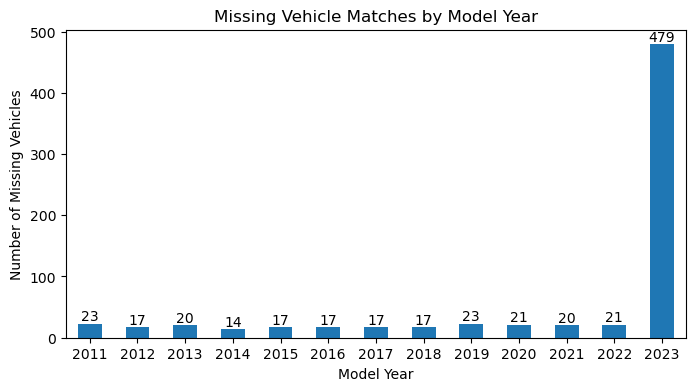

Make         
Ram              156
Porsche           83
Chevrolet         36
Lexus             36
Cadillac          26
Kia               26
Dodge             25
MINI              25
BMW               24
GMC               22
Ford              21
Nissan            20
Maserati          17
Mercedes-Benz     15
Jaguar            15
Bugatti           14
Alfa Romeo        13
Honda             13
Lincoln           12
Volvo             12
Hyundai           11
Bentley            9
Toyota             8
Aston Martin       8
Rolls-Royce        8
Chrysler           7
Mazda              6
Buick              6
Lamborghini        6
Audi               6
Volkswagen         5
Mitsubishi         4
Subaru             4
Suzuki             3
Infiniti           1
FIAT               1
Genesis            1
Acura              1
Name: count, dtype: int64


In [20]:
# find the manufacturer mismatching across the data sheets
missing_vehicles = fc_veh_spec_all[["Model year", "Make", "Model",
                                    "MAKE", "MODEL"]].loc[fc_veh_spec_all["Make"].iloc[:].str.lower() !=
                                                            fc_veh_spec_all["MAKE"].iloc[:].str.lower()]
# Exporting the mismatched vehicle manufacturer to manually inspect the missing vehicles 
missing_vehicles.to_csv("missing_vehicles.csv", index=False)

# Visualising the mismatched vehicle manufacturer to understand its distribution 

plt.figure(figsize=(8,4))

ax = missing_vehicles["Model year"].value_counts().sort_index().plot.bar()

plt.xlabel("Model Year")
plt.ylabel("Number of Missing Vehicles")
plt.title("Missing Vehicle Matches by Model Year")
for p in ax.patches:
    ax.annotate( str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xticks(rotation=0)
plt.show()

#missing_vehicles[["Model year","Make"]].value_counts()
print(missing_vehicles[["Make"]].value_counts())

# Corrective action: retain only the data with correct matching between the make fields across the data sheets

fc_veh_spec_all = fc_veh_spec_all.loc[fc_veh_spec_all["Make"].iloc[:].str.lower() ==
                                                            fc_veh_spec_all["MAKE"].iloc[:].str.lower()]



In [21]:
fc_veh_spec_all

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),...,E,F,G,TWF,TWR,WDIST,MODEL_std,model_fuzzy_key_y,make_std,model_fuzzy_key_hash
0,2011,Acura,CSX,Compact,2.0,4,AS5,X,10.9,7.8,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
1,2011,Acura,CSX,Compact,2.0,4,M5,X,10.0,7.6,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
2,2011,Acura,CSX,Compact,2.0,4,M6,Z,11.6,8.1,...,110.0,92.0,93.0,150.0,151.0,61/39,csx 4dr sedan fwd tech package,"{4dr, sedan, fwd, csx}",acura,"(4dr, sedan, fwd, csx)"
3,2011,Acura,MDX AWD,Sport utility vehicle,3.7,6,AS6,Z,14.8,11.3,...,126.0,100.0,110.0,172.0,172.0,56/44,mdx 4dr suv awd tech elite,"{awd, 4dr, elite, mdx, suv}",acura,"(awd, 4dr, mdx, elite, suv)"
4,2011,Acura,RDX AWD Turbo,Sport utility vehicle,2.3,4,AS5,Z,13.2,10.3,...,124.0,98.0,99.0,158.0,159.0,57/43,rdx 4dr suv awd tech package,"{awd, 4dr, rdx, suv}",acura,"(awd, 4dr, rdx, suv)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13579,2023,Volkswagen,Golf R,Compact,2.0,4,M6,Z,11.8,8.3,...,105.0,88.0,78.0,153.0,151.0,NaN,golf 4dr hatch,"{4dr, hatch, golf}",volkswagen,"(4dr, hatch, golf)"
13585,2023,Volkswagen,Taos,Sport utility vehicle: Small,1.5,4,AS8,X,8.4,6.6,...,102.0,91.0,87.0,157.0,154.0,59/49,taos 4dr suv awd,"{awd, 4dr, taos, suv}",volkswagen,"(awd, 4dr, taos, suv)"
13586,2023,Volkswagen,Taos 4MOTION,Sport utility vehicle: Small,1.5,4,AM7,X,9.5,7.3,...,110.0,97.0,115.0,172.0,172.0,56/44,atlas 4dr suv 4motion,"{4dr, 4motion, atlas, suv}",volkswagen,"(4dr, 4motion, atlas, suv)"
13587,2023,Volkswagen,Tiguan 4MOTION,Sport utility vehicle: Small,2.0,4,AS8,X,10.6,8.0,...,110.0,97.0,115.0,172.0,172.0,56/44,atlas 4dr suv 4motion,"{4dr, 4motion, atlas, suv}",volkswagen,"(4dr, 4motion, atlas, suv)"


### 2. Token Intersection Validation

A validation check was conducted to ensure that the fuzzy matching procedure produced **non-empty token intersections** between the fuel consumption records and the matched vehicle specification records.

Specifically, the field **`join intersection`**, which stores the set of tokens shared between the **fuel consumption token key** and the **vehicle specification token key**, was inspected to identify cases where the intersection size equals **zero**.

Such cases would indicate that a vehicle specification record was assigned as a match despite sharing **no common tokens** with the corresponding fuel consumption record, which would suggest a matching error.

**Result**

The inspection confirmed that **no records contained an empty intersection set**, meaning that every matched pair shares at least **one common token** between the fuel consumption and vehicle specification token keys.

**Corrective Action**

No corrective action was required, as the matching process successfully ensured that all assigned matches have **non-zero token overlap**, indicating a valid minimum level of similarity between the linked records.

In [22]:
fc_veh_spec_all["join intersection"][fc_veh_spec_all["join intersection"].loc[:].apply(len) == 0]

Series([], Name: join intersection, dtype: object)

### 3. Tie case review
A review was conducted to examine records for which the fuzzy matching procedure identified **more than one candidate with the same best similarity score**. These cases are captured in the field **`ties`**, which records the number of tied candidate matches encountered before the final best match was selected using the predefined tie-breaking rules.

The review focused on three aspects:

1. **Frequency of tie cases**  
   The distribution of records with `ties > 0` was inspected to understand how often ambiguous best-match situations occurred.

2. **Simple tie cases with minimal overlap**  
   Records with **exactly one tie** (`ties = 1`) and a **single-token intersection** were examined to identify cases where the final decision was made under very limited shared information.

3. **Highly ambiguous tie cases**  
   Records with a **large number of tied candidates** (`ties ≥ 5`) and a **single-token intersection** were also reviewed, as these represent the most ambiguous matching situations and therefore the highest potential risk for incorrect assignment.

**Result**

The inspection showed that tie cases do occur, but the most ambiguous cases are concentrated in records where the matched token overlap is limited to **one shared token**. The unique intersection sets observed in these cases were extracted for manual review to assess whether the selected matches remained reasonable under the tie-breaking rules.

This review provides additional quality assurance for the fuzzy matching stage by highlighting records where the best-match decision depended on limited discriminatory information.

**Corrective Action**

Tie cases with minimal overlap were flagged as part of the matching diagnostics for closer inspection. The existing tie-breaking strategy was retained, as it applies a consistent decision hierarchy based on:

- the number of **strong (non-weak) tokens** in the intersection,
- the **intersection size**,
- and the **union size**.

These checks improve transparency in the matching process and help identify records that may require future refinement of the matching rules if necessary.

In [23]:
fc_veh_spec_all.columns

Index(['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)',
       'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)',
       'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)',
       'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating', 'Model_std',
       'Vehicle class_std', 'cylinders_std', 'model_fuzzy_key_x', 'ties',
       'similarity ratio', 'join intersection', 'fc_join_key',
       'veh_spec_join_key', 'veh_spec_join_key_hash', 'MAKE', 'MODEL', 'MYR',
       'OL', 'OW', 'OH ', 'WB', 'CW ', 'A', 'B', 'C', 'D', 'E', 'F', 'G',
       'TWF', 'TWR ', 'WDIST', 'MODEL_std', 'model_fuzzy_key_y', 'make_std',
       'model_fuzzy_key_hash'],
      dtype='object')

In [24]:
fc_veh_spec_all["ties"][fc_veh_spec_all["ties"].loc[:] > 0].value_counts()

ties
1     3102
2      569
3      372
5      261
4       73
21      59
22      53
19      48
23      27
9       25
7       16
11       8
6        6
17       5
20       5
10       1
Name: count, dtype: int64

In [25]:
fc_veh_spec_all["join intersection"][(fc_veh_spec_all["ties"].loc[:] == 1) & (fc_veh_spec_all["join intersection"].loc[:].apply(len) == 1)].unique

<bound method Series.unique of 9            {tsx}
10           {tsx}
26            {a4}
76          {328i}
77          {328i}
           ...    
13535    {corolla}
13543    {corolla}
13561        {4wd}
13562        {4wd}
13564     {tundra}
Name: join intersection, Length: 858, dtype: object>

In [26]:
fc_veh_spec_all["join intersection"].loc[
                                        (fc_veh_spec_all["ties"] >= 5) &
                                        (fc_veh_spec_all["join intersection"].apply(len) == 1)].apply(tuple).unique()

array([('colorado',), ('hhr',), ('silverado',), ('canyon',), ('sierra',),
       ('suv',), ('camaro',), ('hatchback',), ('coupe',), ('mazda3',),
       ('amg',)], dtype=object)

### 4. Final Dataset Standardisation and Export

After completing the fuzzy matching process and validating the join quality, the integrated dataset was standardised to produce a **clean, analysis-ready dataframe**.

The following steps were performed:

**1. Column name cleaning**  
Leading and trailing whitespace characters were removed from all column names to avoid inconsistencies caused by formatting artefacts.

**2. Vehicle specification field renaming**  
The abbreviated vehicle specification attributes were renamed according to the official **vehicle specification data catalogue** to improve interpretability.  
Examples include:

- `OL` → `overall_length`
- `OW` → `overall_width`
- `OH` → `overall_height`
- `WB` → `wheelbase`
- `CW` → `curb_weight`
- `TWF` → `track_width_front`
- `TWR` → `track_width_rear`
- `WDIST` → `weight_distribution`

In addition, the original specification identifiers were renamed for clarity:

- `MAKE` → `vehicle_specification_make`
- `MODEL` → `vehicle_specification_model`
- `MYR` → `measurements_obtained_in_year`

**3. Column name standardisation**  
All remaining column names were standardised by:

- converting text to **lowercase**
- replacing spaces with **underscores**
- removing parentheses
- replacing `/` with `_per_` to maintain valid variable names

This step ensures the dataset follows a **consistent naming convention suitable for data analysis and machine learning workflows**.

**4. Removal of matching diagnostic fields**  
Intermediate variables created during the fuzzy matching stage (e.g., join keys, similarity metrics, and diagnostic columns) were removed to retain only the relevant **vehicle attributes and fuel consumption variables** required for analysis.

**5. Final dataset export**  
The cleaned and standardised dataset was exported as:

In [27]:

# remove white spaces
fc_veh_spec_all.columns = fc_veh_spec_all.columns.str.strip()

# rename vehicle specification fields according to the provided data catalogue
rename_dict = {"OL": "overall_length",
               "OW": "overall_width",
               "OH": "overall_height",
               "WB": "wheelbase",
               "CW": "curb_weight",
               "A": "front_end_length",
               "B": "rear_end_length",
               "C": "side_glass_height",
               "D": "body_side_height",
               "E": "roof_width",
               "F": "front_overhang",
               "G": "rear_overhang",
               "TWF": "track_width_front",
               "TWR": "track_width_rear",
               "WDIST": "weight_distribution",
               "MYR" : "measurements_obtained_in_year",
               "MAKE" : "vehicle_specification_make",
               "MODEL" : "vehicle_specification_model"}

fc_veh_spec_all = fc_veh_spec_all.rename(columns=rename_dict)

# standardise remaining names
fc_veh_spec_all.columns = (fc_veh_spec_all.columns
                           .str.lower()
                           .str.replace(" ", "_")
                           .str.replace("(", "", regex=False)
                           .str.replace(")", "", regex=False)
                           .str.replace("/", "_per_", regex=False))



# remove matching fields diagnostics fields
fc_veh_spec_all = fc_veh_spec_all[['model_year', 'make', 'model', 'vehicle_class', 'engine_size_l', 'cylinders', 'transmission',
                                  'fuel_type', 'city_l_per_100_km', 'highway_l_per_100_km', 'combined_l_per_100_km', 'combined_mpg',
                                  'co2_emissions_g_per_km', 'co2_rating', 'smog_rating',
                                  'vehicle_specification_make', 'vehicle_specification_model', 'measurements_obtained_in_year', 'overall_length', 'overall_width', 'overall_height',
                                  'wheelbase', 'curb_weight', 'front_end_length', 'rear_end_length', 'side_glass_height', 'body_side_height', 
                                  'roof_width',  'front_overhang', 'rear_overhang', 'track_width_front', 'track_width_rear', 'weight_distribution']] 

fc_veh_spec_all.to_csv("fc_veh_spec_all.csv",index= False)

## End of the data construction

# EDA workflow:
